In [6]:
%matplotlib inline

In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
#Load openfoam data
data1 = np.loadtxt("../postProcessing/surfacesDict/5000/grad(U)_wall.raw",skiprows=2)
data2 = np.loadtxt("./ercoftac_t3a_cf.dat",skiprows=0)

In [9]:
#Define variables
#x=np.linspace(-1,3,1000)
x=data1[:,0]

U = 5.4
nu = 1.5e-05
rho = 1.186

In [10]:
#Compute Re_x
re_x=U*x/nu

In [11]:
#Compute tau laminar and cf from correlation
taulam = nu*U*np.sqrt(U/(nu*x))*0.332
cflam_x = 2*taulam/(U**2)

In [12]:
#Compute tau turbulent and cf from correlation - white
tauturb = 0.455/(np.log(0.06*re_x))**2
cfturb_x=2*tauturb/(U**2)

In [13]:
#Compute friction coefficient using grad(U) computed in openfoam
cf_x=2*data1[:,6]*nu/(U**2)

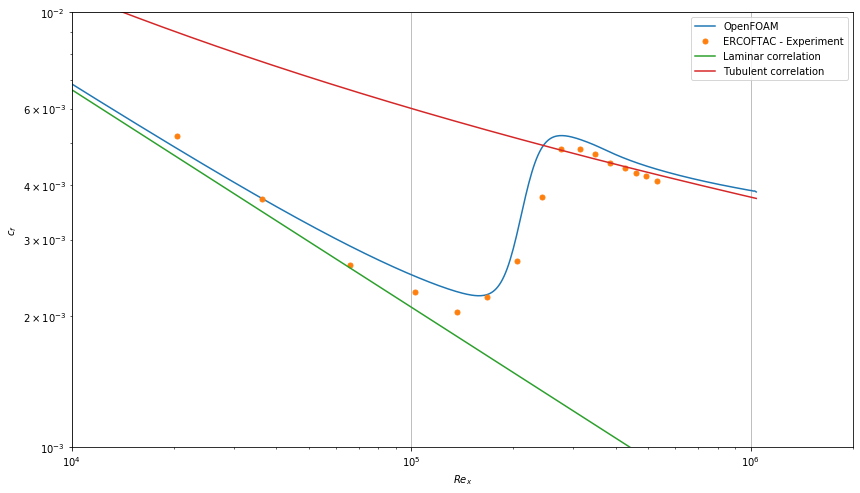

In [14]:
#Plot law of wall

#Plot profiles
plt.figure(figsize=(14, 8))


plt.plot(re_x,cf_x,label='OpenFOAM')
plt.plot(data2[:,0],data2[:,1],'o', ms=5,label='ERCOFTAC - Experiment')
plt.plot(re_x,cflam_x,'-', ms=5,label='Laminar correlation')
plt.plot(re_x,tauturb,'-', ms=5,label='Tubulent correlation')
#plt.plot(re_x,cfturb_x,'-', ms=5,label='Tubulent correlation')

#plt.plot(yp,up1,label='Log-law)

plt.xscale('log')
plt.yscale('log')

plt.xlim(10000,2000000)
plt.ylim(0.001,0.01)

plt.xlabel("$Re_x$")
plt.ylabel("$c_f$")

plt.grid()
plt.legend(loc=0)

#plt.savefig('cf5000.png')